In [1]:
# Install necessary libraries
!pip install shap transformers datasets torch scikit-learn

# Import libraries
import torch
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from transformers.data.data_collator import DataCollatorWithPadding
from datasets import Dataset
import numpy as np # Import numpy and assign it to the alias 'np'

# Step 1: Upload and Load Dataset
# from google.colab import files
# uploaded = files.upload()  # Upload the dataset file
# DATA_FILE = list(uploaded.keys())[0]  # Get the uploaded file name
DATA = pd.read_csv("DefaktS_Twitter.csv")
DATA['label'] = DATA['binary_label'].astype(int)
DATA['text'] = DATA['text'].str.replace(r"https:\/\/t.co\/\S+", "[URL]", regex=True)

# Step 2: Balance the dataset
minority_class = DATA[DATA['label'] == 1]
majority_class = DATA[DATA['label'] == 0]
oversampled_minority = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)
balanced_data = pd.concat([majority_class, oversampled_minority])

# Step 3: Train-Test Split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, stratify=balanced_data['label'], random_state=42
)

# Step 4: Compute Class Weights
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Step 5: Convert to Hugging Face Dataset
train_dataset = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
test_dataset = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})

# Step 6: Tokenizer and Base Model
#MODEL_NAME = "distilbert-base-uncased"
MODEL_NAME = "distilbert-base-german-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Custom model class to include class weights and dropout
class WeightedBERT(torch.nn.Module):
    def __init__(self, model, class_weights):
        super(WeightedBERT, self).__init__()
        self.model = model
        self.dropout = torch.nn.Dropout(0.4)  # Increased dropout for regularization
        self.register_buffer("class_weights", class_weights)

    def forward(self, input_ids, attention_mask, labels=None):
        device = input_ids.device
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.dropout(outputs.logits)  # Apply dropout
        loss = None
        if labels is not None:
            loss = torch.nn.functional.cross_entropy(logits, labels, weight=self.class_weights)
        return {"loss": loss, "logits": logits}

# Load Pretrained BERT Model and Wrap It
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = WeightedBERT(base_model, class_weights)

# Step 7: Tokenize the Dataset
def tokenize_function(sample):
    return tokenizer(sample['text'], truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Step 8: Data Collator for Dynamic Padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Step 9: Define Evaluation Metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Step 10: Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    weight_decay=0.2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    lr_scheduler_type="cosine_with_min_lr",
    warmup_steps=500,
    lr_scheduler_kwargs={"min_lr": 1e-6},
    report_to=[],
)

# Step 11: Initialize Trainer with Early Stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Step 12: Train the Model
trainer.train()

# # Step 13: Save the Model
# model.save_pretrained("./saved_model")
# tokenizer.save_pretrained("./saved_model")

# Save the base Hugging Face model (inside WeightedBERT)
model.model.save_pretrained("./saved_model")  # Save the underlying Hugging Face model
tokenizer.save_pretrained("./saved_model")  # Save the tokenizer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/240k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/479k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/270M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-german-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/18833 [00:00<?, ? examples/s]

Map:   0%|          | 0/4709 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.438800,0.306295,0.867488,0.868742,0.860417,0.877230
2,0.271300,0.309257,0.887874,0.883956,0.915756,0.854291
3,0.277000,0.320376,0.908048,0.908553,0.903402,0.913764
4,0.221100,0.425072,0.913357,0.912821,0.918315,0.907392
5,0.196400,0.466174,0.911446,0.911746,0.908477,0.915038


('./saved_model/tokenizer_config.json',
 './saved_model/special_tokens_map.json',
 './saved_model/vocab.txt',
 './saved_model/added_tokens.json',
 './saved_model/tokenizer.json')

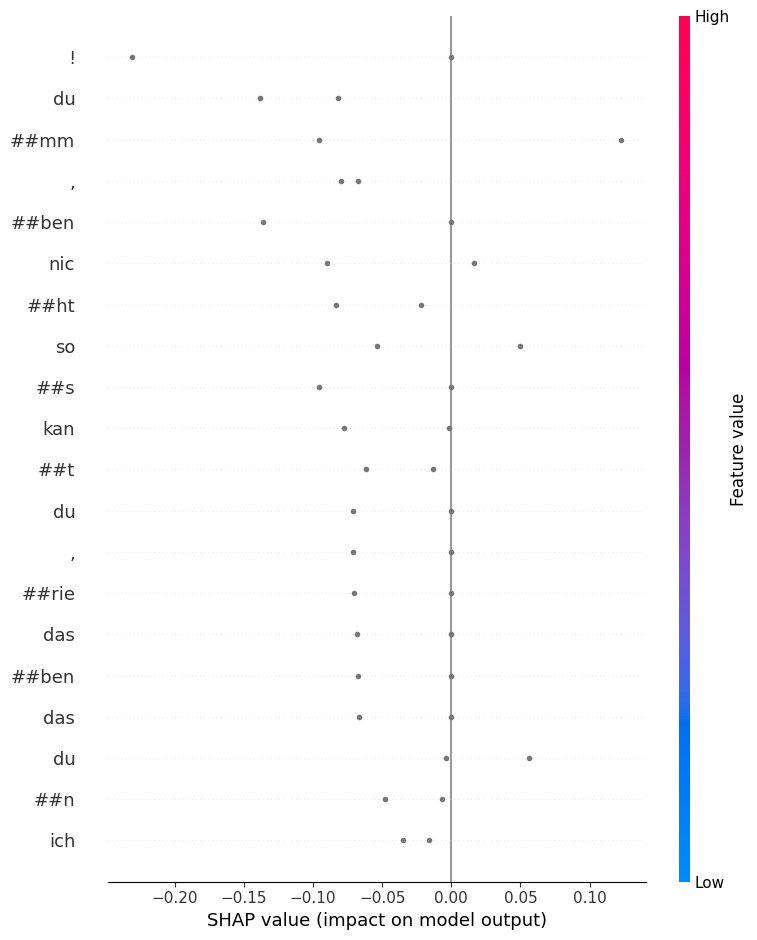


Force Plot for Sample 1: Du bist so dumm, ich kann nicht glauben, dass du das geschrieben hast!


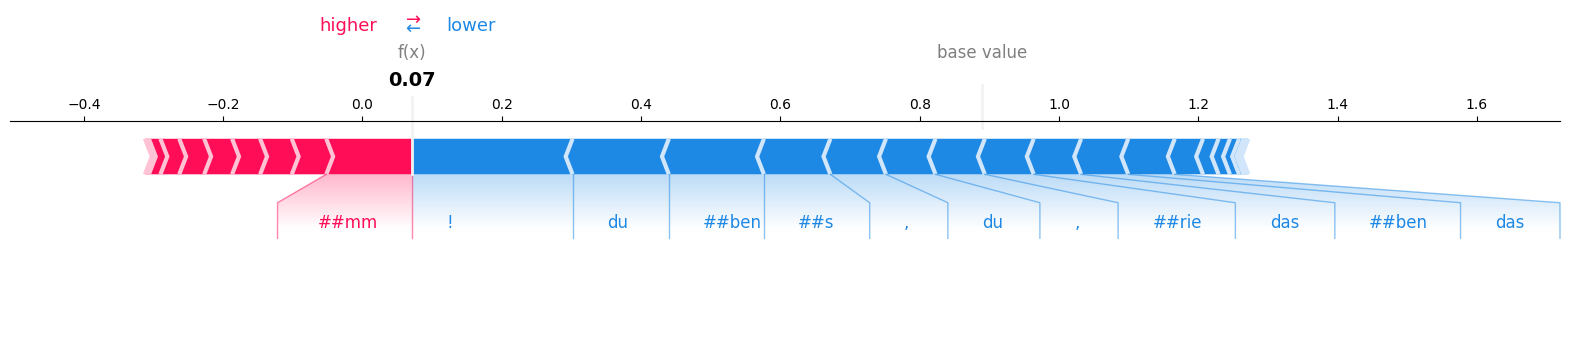


Force Plot for Sample 2: Ich wünsche dir einen schönen Tag!


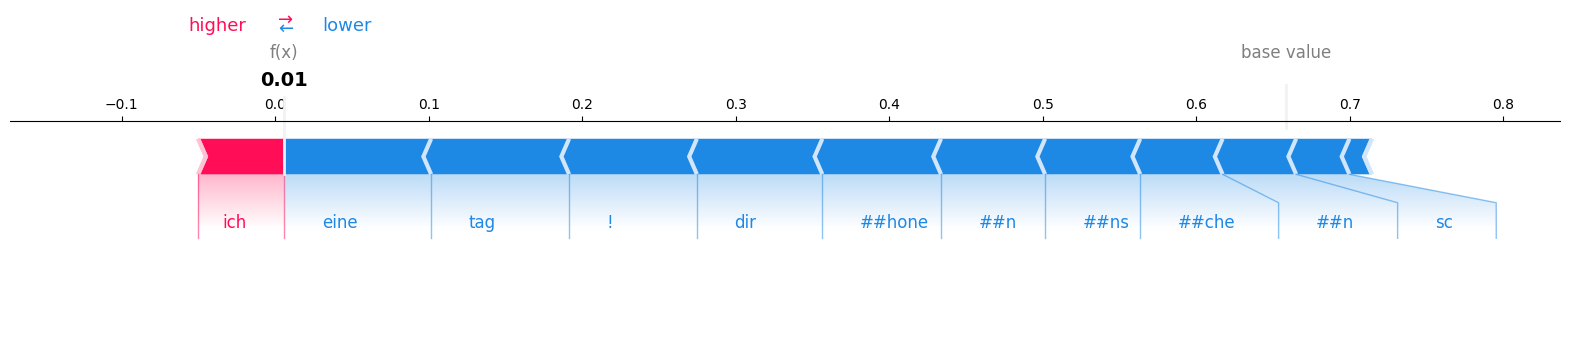

In [ ]:
# Install required libraries
!pip install shap transformers torch

# Import libraries
import shap
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the trained model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("./saved_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Define predict_proba for SHAP
def predict_proba(texts):
    # Ensure input is in the correct format
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, list) and all(isinstance(t, list) for t in texts):
        texts = [" ".join(tokens) for tokens in texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError(f"Unexpected input format: {type(texts)}")

    # Tokenize the input texts
    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    # Predict probabilities
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Initialize SHAP Explainer with Text Masker
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)

# SHAP Analysis on Example Texts
sample_texts = [
    "Du bist so dumm, ich kann nicht glauben, dass du das geschrieben hast!",  # Toxic
    "Ich wünsche dir einen schönen Tag!",  # Non-toxic
]

# Compute SHAP values for the sample texts
shap_values = explainer(sample_texts)

# Extract Tokens and SHAP Values
tokens_list = [
    tokenizer.convert_ids_to_tokens(tokenizer(sample, truncation=True)["input_ids"])
    for sample in sample_texts
]

# Compute SHAP values and normalize
max_len = max(len(value.values) for value in shap_values)  # Find the max length of SHAP values

# Normalize SHAP values and tokens
normalized_shap_values = [
    np.pad(value.values[:, 1], (0, max_len - len(value.values[:, 1])), constant_values=0)
    for value in shap_values
]
normalized_tokens = [
    tokens + ['[PAD]'] * (max_len - len(tokens)) for tokens in tokens_list
]

# Convert normalized SHAP values to a NumPy array
normalized_shap_values = np.array(normalized_shap_values)

# SHAP Summary Plot with Feature Names
shap.initjs()
shap.summary_plot(
    shap_values=normalized_shap_values,   # Normalized SHAP values
    features=np.array(normalized_tokens),  # Tokens as features
    feature_names=normalized_tokens[0]    # Explicitly pass tokens as feature names
)



# SHAP Force Plot
for i, text in enumerate(sample_texts):
    print(f"\nForce Plot for Sample {i + 1}: {text}")
    shap.force_plot(
        base_value=shap_values[i].base_values[1],  # Base value for the positive class
        shap_values=shap_values[i].values[:, 1],  # SHAP values for the positive class
        features=tokens_list[i],                  # Tokens for the sample
        matplotlib=True                           # Render using Matplotlib
    )



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Selected Sample Texts:
Sample 1: Irgendwie mittlerweile Händchen dafür Liberale mehr triggern Rechten Paradox dachte pro Meinungsfreiheit Hört SpringerBashing leider Melden gedroht ¯\ツ¯
Sample 2: 🇺🇸 Elon Musk wurde neuen SocialMediaGesetz Europäischen Union gewarnt Block sagt Überwachung Einhaltung Twitter wachsam vereinigtestaaten meistgeteilt httpstcolMklaJFSTp
Sample 3: Herr Bundeskanzler gibt deutsches Volk afdfraktion bundestag httpstcolHIAUdpU via YouTube
Sample 4: Zwischenbericht EnqueteKommission „ Konsequenzen Flutkatastrophe RheinlandPfalz PDF httpstcoYwBiPBU


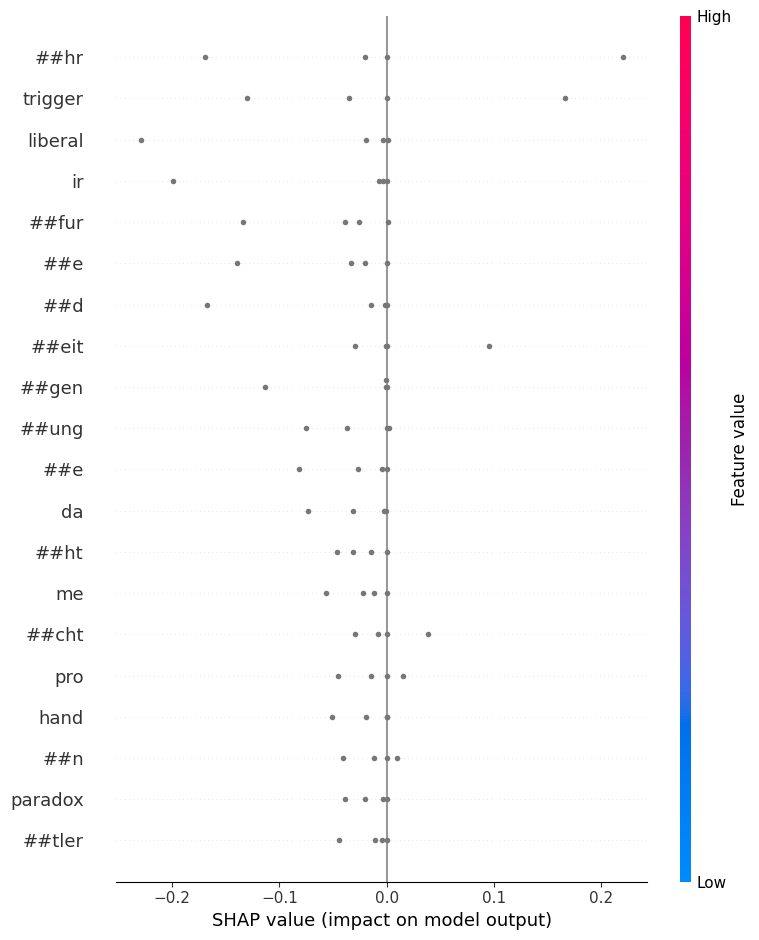


Force Plot for Sample 1: Irgendwie mittlerweile Händchen dafür Liberale mehr triggern Rechten Paradox dachte pro Meinungsfreiheit Hört SpringerBashing leider Melden gedroht ¯\ツ¯


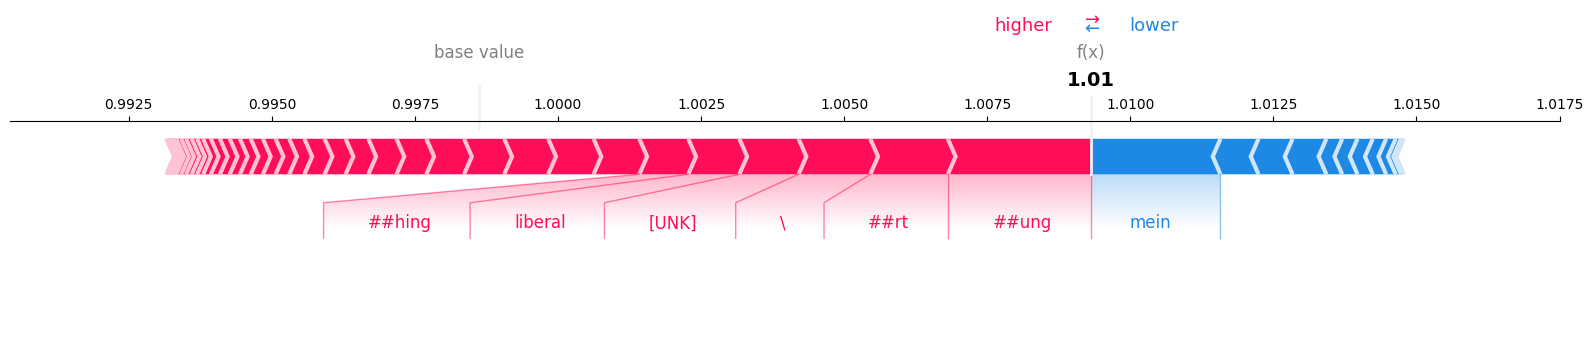


Force Plot for Sample 2: 🇺🇸 Elon Musk wurde neuen SocialMediaGesetz Europäischen Union gewarnt Block sagt Überwachung Einhaltung Twitter wachsam vereinigtestaaten meistgeteilt httpstcolMklaJFSTp


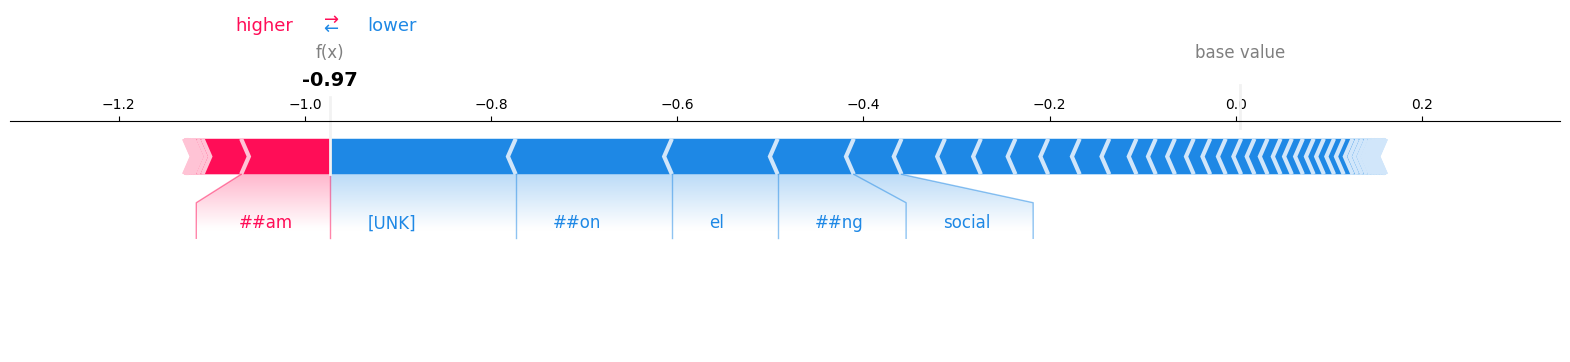


Force Plot for Sample 3: Herr Bundeskanzler gibt deutsches Volk afdfraktion bundestag httpstcolHIAUdpU via YouTube


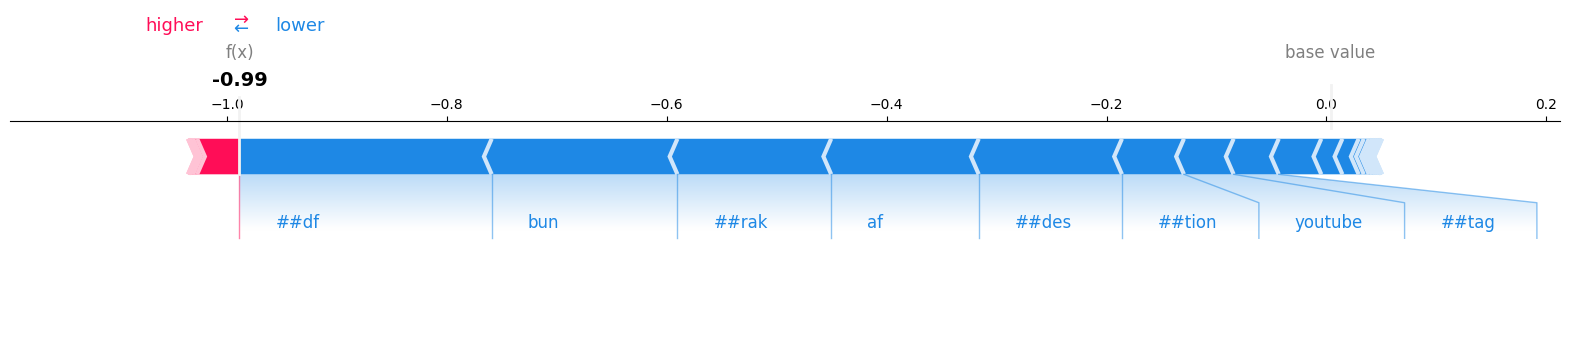


Force Plot for Sample 4: Zwischenbericht EnqueteKommission „ Konsequenzen Flutkatastrophe RheinlandPfalz PDF httpstcoYwBiPBU


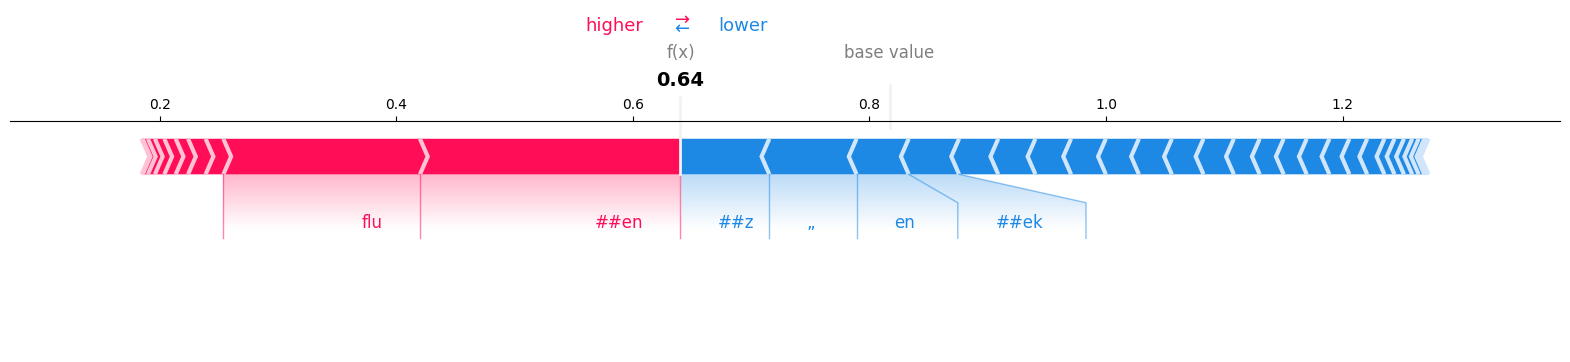

In [ ]:
# Install required libraries
!pip install shap transformers torch nltk

# Download required NLTK data
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

# Import libraries
import shap
import torch
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
import re

# Load German stop words
german_stop_words = set(stopwords.words('german'))

# Function to remove German stop words
def remove_stopwords(text):
    words = word_tokenize(text, language='german')
    filtered_words = [word for word in words if word.lower() not in german_stop_words]
    return " ".join(filtered_words)

# Function to remove special characters
def remove_special_chars(text):
    """Removes specified special characters from the given text, including nested brackets."""
    pattern = r"[.,;()\[\]{}!?:@#$%^&*()_+-=<>?/]"
    text = re.sub(r'\s+', ' ', text)
    return re.sub(pattern, '', text)

# Load the trained model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("./saved_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Define predict_proba for SHAP
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError(f"Unexpected input format: {type(texts)}")

    # Apply stop word removal and special character removal
    texts = [remove_stopwords(remove_special_chars(text)) for text in texts]

    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Load dataset
data = pd.read_csv('DefaktS_Twitter.csv')

# Preprocessing
data['text'] = data['text'].apply(remove_special_chars)
data['text'] = data['text'].apply(remove_stopwords)

# Split data into train and test sets
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# Initialize SHAP Explainer with Text Masker
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)

# Select random sample texts from the test dataset
sample_texts = test_df.sample(4, random_state=42)["text"].tolist()

# Print the selected sample texts
print("Selected Sample Texts:")
for i, text in enumerate(sample_texts, 1):
    print(f"Sample {i}: {text}")

# Compute SHAP values
shap_values = explainer(sample_texts)

# Extract tokens and SHAP values, ensuring consistent length
max_len = 128
normalized_shap_values = []
normalized_tokens = []
for sample, value in zip(sample_texts, shap_values):
    tokens = tokenizer.convert_ids_to_tokens(tokenizer(sample, truncation=True, max_length=max_len, padding=True)['input_ids'])
    shap_vals = value.values[:, 1]

    normalized_shap_values.append(
        np.pad(shap_vals, (0, max_len - len(shap_vals)), constant_values=0)[:max_len]
    )
    normalized_tokens.append(tokens[:max_len] + ['[PAD]'] * (max_len - len(tokens[:max_len])))

# Filter out [PAD] tokens before visualization
filtered_shap_results = []
for shap_values_row, tokens_row in zip(normalized_shap_values, normalized_tokens):
    filtered_shap_values = [val for val, token in zip(shap_values_row, tokens_row) if token != '[PAD]']
    filtered_tokens = [token for token in tokens_row if token != '[PAD]']
    filtered_shap_results.append((filtered_shap_values, filtered_tokens))

# Pad SHAP values to equal length for visualization
max_len_filtered = max(len(result[0]) for result in filtered_shap_results)
padded_shap_values = [np.pad(result[0], (0, max_len_filtered - len(result[0])), constant_values=0) for result in filtered_shap_results]

# Pad tokens for visualization
padded_tokens = [result[1] + ['[PAD]'] * (max_len_filtered - len(result[1])) for result in filtered_shap_results]

# SHAP Summary Plot
shap.initjs()
shap.summary_plot(
    shap_values=np.array(padded_shap_values),
    features=np.array(padded_tokens),
    feature_names=padded_tokens[0],
)

# SHAP Force Plot
for i, text in enumerate(sample_texts):
    print(f"\nForce Plot for Sample {i + 1}: {text}")
    expected_value = explainer.expected_value[1] if explainer.expected_value is not None else predict_proba([text])[0][1]
    tokens = tokenizer.convert_ids_to_tokens(tokenizer(text, truncation=True, max_length=max_len, padding=True)['input_ids'])
    shap.force_plot(
        expected_value,
        shap_values[i].values[:, 1],
        features=tokens,
        matplotlib=True
    )

In [ ]:
# Calculate feature importance
feature_importance = np.mean(np.abs(normalized_shap_values), axis=0)

# Create a list of tokens with their importance
feature_importance_data = list(zip(normalized_tokens[0], feature_importance))

# Sort tokens by importance
sorted_feature_importance = sorted(feature_importance_data, key=lambda x: x[1], reverse=True)

# Display Top 10 Most Important Features
print("\nTop 10 Most Important Features (Tokens):")
for token, importance in sorted_feature_importance[:10]:
    print(f"Token: {token}, Importance: {importance:.4f}")

# Save Feature Importance to CSV
import csv
with open("feature_importance.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Token", "Importance"])
    writer.writerows(sorted_feature_importance)

print("\nFeature importance saved to 'feature_importance.csv'.")



Top 10 Most Important Features (Tokens):
Token: ##hr, Importance: 0.1024
Token: trigger, Importance: 0.0830
Token: liberal, Importance: 0.0632
Token: ir, Importance: 0.0525
Token: ##fur, Importance: 0.0498
Token: ##e, Importance: 0.0484
Token: ##d, Importance: 0.0460
Token: ##eit, Importance: 0.0313
Token: ##gen, Importance: 0.0288
Token: ##ung, Importance: 0.0287

Feature importance saved to 'feature_importance.csv'.


In [ ]:
!pip freeze > requirements.txt

In [ ]:
!zip -r /content/Twitter.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_update_check.json (deflated 23%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.01.16/ (stored 0%)
  adding: content/.config/logs/2025.01.16/14.28.59.271536.log (deflated 58%)
  adding: content/.config/logs/2025.01.16/14.28.29.838121.log (deflated 93%)
  adding: content/.config/logs/2025.01.16/14.29.08.514080.log (deflated 57%)
  adding: content/.config/logs/2025.01.16/14.28.58.277099.log (deflated 87%)
  adding: content/.c

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rsync -avP /content/Twitter.zip /content/drive/MyDrive/

sending incremental file list
Twitter.zip
    865,422,161 100%  366.64MB/s    0:00:02 (xfr#1, to-chk=0/1)

sent 865,633,546 bytes  received 35 bytes  247,323,880.29 bytes/sec
total size is 865,422,161  speedup is 1.00
